In [5]:
import sys
sys.path.insert(0, '..')

In [6]:
pip install pd

Note: you may need to restart the kernel to use updated packages.


In [8]:
# Parameters

from utils.dynamicRieszFunctions import estimateDynamicRiesz_all
from utils.dynamicRieszFunctions import estimateDynamicRiesz
from utils.estimateDiDLinear import estimateDiDLinear
from utils.estimateDiD_OLS import estimateDiD_OLS
import torch
import pandas as pd
import time
from torch.distributions import Normal
from utils.dgp import DiD_DGP
import statsmodels.api as sm

from utils.application import *
from tqdm import tqdm
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import numpy as np
import pandas as pd

lasso_cv_settings = {
    'b_degree' : 1,
    'cv_folds' : 5,
    'random_state' : 42
}

lasso_a_settings = {
    'lambda_val' : 10,
    'beta_start' : None,
    'D_LB' : 0,
    'D_add' : 0.2,
    'c1' : "CV",
    'c2' : 0.1,
    'tol' : 1e-5,
    'max_iter' : 100,
    'b_degree' : 1,
    'control' : {'maxIter': 1000, 'optTol': 1e-5, 'zeroThreshold': 1e-6}
}

lasso_f_settings = {
    'lambda_val' : 10,
    'beta_start' : None,
    'D_LB' : 0,
    'D_add' : 0.2,
    'c1' :  "CV",
    'c2' : 0.1,
    'tol' : 1e-5,
    'max_iter' : 100,
    'b_degree' : 1,
    'control' : {'maxIter': 1000, 'optTol': 1e-5, 'zeroThreshold': 1e-6}
}

rf_a_settings = {
    'poly_degree' : 0,
    'l2' : 0,
    'n_estimators' : 10,
    'criterion' : "mse",
    'max_depth' : None,
    'min_samples_split' : 10,
    'min_samples_leaf' : 5,
    'min_weight_fraction_leaf' : 0.,
    'min_var_fraction_leaf' : None,
    'min_var_leaf_on_val' : False,
    'max_features' : "auto",
    'min_impurity_decrease' : 0.,
    'max_samples' : .45,
    'min_balancedness_tol' : .45,
    'honest' : True,
    'inference' : True,
    'fit_intercept' : True,
    'subforest_size' : 2,
    'n_jobs' : 1,
    'random_state' : None
    
    
    ,

    'verbose' : 0,
    'warm_start' : False
}
rf_f_settings = {
    'poly_degree' : 1, # 1 or 2?
    'l2' : 0,
    'n_estimators' : 10,
    'criterion' : "mse",
    'max_depth' : None,
    'min_samples_split' : 10,
    'min_samples_leaf' : 5,
    'min_weight_fraction_leaf' : 0.,
    'min_var_fraction_leaf' : None,
    'min_var_leaf_on_val' : False,
    'max_features' : "auto",
    'min_impurity_decrease' : 0.,
    'max_samples' : .45,
    'min_balancedness_tol' : .45,
    'honest' : True,
    'inference' : True,
    'fit_intercept' : True,
    'subforest_size' : 2,
    'n_jobs' : 1,
    'random_state' : None,
    'verbose' : 0,
    'warm_start' : False
}

net_a_settings = {
    'test_split' : 0,
    'learner_lr' : 1e-4,
    'learner_l2' : 1e-3,
    'learner_l1' : 0,
    'n_epochs' : 100,
    'earlystop_rounds' : 20,
    'earlystop_delta' : 1e-3,
    'bs' : 64,
    'optimizer' : 'adam',
    'warm_start' : False,
    'logger' : None,
    'model_dir' : '.',
    'device' : torch.cuda.current_device() if torch.cuda.is_available() else None,
    'n_hidden' : 100,
    'drop_prob' : 0,
    'degree' : 2,
    'interaction_only' : True,
    'n_common' : 200,
    'act_func' : 'elu'
}

net_f_settings = {
    'test_split' : 0,
    'learner_lr' : 1e-4,
    'learner_l2' : 1e-3,
    'learner_l1' : 0,
    'n_epochs' : 100,
    'earlystop_rounds' : 20,
    'earlystop_delta' : 1e-3,
    'bs' : 64,
    'optimizer' : 'adam',
    'warm_start' : False,
    'logger' : None,
    'model_dir' : '.',
    'device' : torch.cuda.current_device() if torch.cuda.is_available() else None,
    'n_hidden' : 100,
    'drop_prob' : 0,
    'degree' : 2,
    'interaction_only' : True,
    'n_common' : 200,
    'act_func' : 'elu'
}



In [9]:
def dynamic_riesz_results(start_year: int,
                          effect_year: int,
                          treatment_year: int = 2004, 
                          baseline_2001: bool = True,
                          folds: int = 5,
                          seed: int = 0) -> pd.DataFrame:

    data_app = application_data()
    data = data_app.get_data(start_year, effect_year,treatment_year= treatment_year ,baseline_2001=baseline_2001)
    X1, X2 = data['X1'], data['X2']
    Y1, Y2 = data['Y1'], data['Y2']
    Z, D   = data['Z'],  data['D']

    Z_df  = pd.DataFrame(Z.numpy())
    X1_df = pd.DataFrame(X1.numpy())


    X_cov = pd.concat(
        [pd.DataFrame(D.numpy(), columns=["D"]), Z_df, X1_df],
        axis=1
    )
    Ydiff = np.asarray(Y2) - np.asarray(Y1)
    X_cov = sm.add_constant(X_cov)
    ols2 = sm.OLS(Ydiff, X_cov).fit(cov_type="HC1")
    rows = []
    rows.append({
        "method": "OLS YDiff on Z, X1, and D",
        "ATT":    float(ols2.params["D"]),
        "SE":     float(ols2.bse["D"])
    })

    lin_out = estimateDiD_OLS(Y1, Y2, D, Z, X1, X2,seed=seed)
    rows.append({
            "method": "Caetano",
            "ATT":    lin_out[0],
            "SE":     lin_out[1]}
            )

    for method in ("LASSO", "RF", "Net"):
        ATT, STD, *_ = estimateDynamicRiesz(
            Y1, Y2, D, Z, X1, X2,
            folds,
            method_a=method,
            method_f=method,
            seed=seed
        )
        se = STD / np.sqrt(len(Y1))
        rows.append({
            "method": method,
            "ATT":    ATT.item(),
            "SE":     se.item()
        })

    return pd.DataFrame(rows)



def plot_att_estimates_with_ci(out_df, att_manual, std_manual, manual_label, year, santAnna_att, santAnna_std ):

    manual_df = pd.DataFrame({
        'method': [manual_label],
        'ATT':    [att_manual],
        'SE':     [std_manual]
    })
    
    santAnna = pd.DataFrame({
        'method': ["SantAnna Conditional PTA DR"],
        'ATT':    [santAnna_att],
        'SE':     [santAnna_std]
    })

    # Combine all estimates
    plot_df = pd.concat([santAnna, manual_df, out_df], ignore_index=True)

    # Explicit ordering: OLS first, then others, then ML
    method_order = [
        "OLS YDiff on Z, X1, and D",
        "SantAnna Conditional PTA DR", 
        manual_label, 
        "Caetano", 
        "LASSO", 
        "RF", 
        "Net"
    ]

    plot_df["method"] = pd.Categorical(plot_df["method"], categories=method_order, ordered=True)
  

    plot_df = plot_df.sort_values("method")
    # Plot
    fig, ax = plt.subplots()
    ax.errorbar(
        plot_df['method'],
        plot_df['ATT'],
        yerr=1.96 * plot_df['SE'],  
        fmt='o',
        capsize=5
    )
    ax.axhline(0, linestyle='--', color='gray')
    ax.set_ylabel('ATT Estimate')
    ax.set_title(f'ATT Estimates with 95% Confidence Intervals: {year}')
    ax.set_ylim(-0.13, 0.02)
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()





# 2004

In [6]:
# Automatic Debiased Machine Learning for Covariate Shifts
out_2004 = dynamic_riesz_results(2003,2004)



Changing covariates:  ['lpop', 'lavg_pay']
Z variables:  ['region_2', 'region_3', 'region_4', '2001_lemp', '2001_lpop', '2001_lavg_pay']


Exception ignored in: <finalize object at 0x151f66c3cd60; dead>
Traceback (most recent call last):
  File "/n/home11/jinhopark/.conda/envs/riesz/lib/python3.10/weakref.py", line 591, in __call__
    return info.func(*info.args, **(info.kwargs or {}))
  File "/n/home11/jinhopark/.conda/envs/riesz/lib/python3.10/tempfile.py", line 868, in _cleanup
    cls._rmtree(name, ignore_errors=ignore_errors)
  File "/n/home11/jinhopark/.conda/envs/riesz/lib/python3.10/tempfile.py", line 864, in _rmtree
    _shutil.rmtree(name, onerror=onerror)
  File "/n/home11/jinhopark/.conda/envs/riesz/lib/python3.10/shutil.py", line 731, in rmtree
    onerror(os.rmdir, path, sys.exc_info())
  File "/n/home11/jinhopark/.conda/envs/riesz/lib/python3.10/shutil.py", line 729, in rmtree
    os.rmdir(path)
OSError: [Errno 39] Directory not empty: '/n/home11/jinhopark/tmpp199j01s'
Exception ignored in: <finalize object at 0x151f66c38da0; dead>
Traceback (most recent call last):
  File "/n/home11/jinhopark/.conda/envs/

In [7]:
att_2014, std_2014 =-0.022,0.019
att_SantAnna, std_SantAnna = -0.0303     , 0.0225    

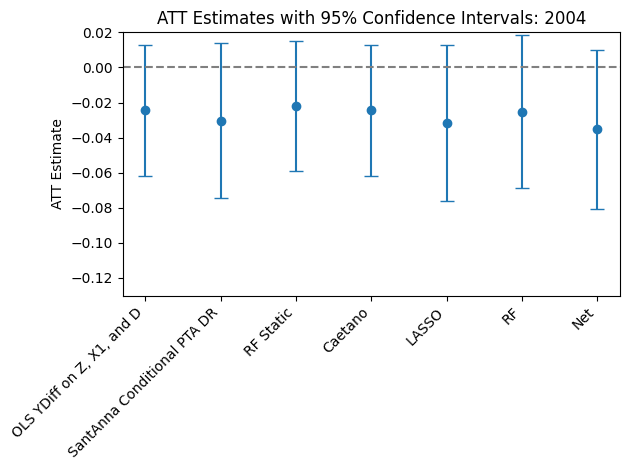

In [8]:
out = plot_att_estimates_with_ci(out_2004, att_2014, std_2014, 'RF Static', "2004",att_SantAnna, std_SantAnna )

In [13]:
out

## 2005

In [4]:
out_2005 = dynamic_riesz_results(2003,2005)
att_2015, std_2015 = -0.049,0.020
att_SantAnna, std_SantAnna= -0.0247,     0.0217  

Changing covariates:  ['lpop', 'lavg_pay']
Z variables:  ['region_2', 'region_3', 'region_4', '2001_lemp', '2001_lpop', '2001_lavg_pay']


Exception ignored in: <finalize object at 0x148a758a1040; dead>
Traceback (most recent call last):
  File "/n/home11/jinhopark/.conda/envs/riesz/lib/python3.10/weakref.py", line 591, in __call__
    return info.func(*info.args, **(info.kwargs or {}))
  File "/n/home11/jinhopark/.conda/envs/riesz/lib/python3.10/tempfile.py", line 868, in _cleanup
    cls._rmtree(name, ignore_errors=ignore_errors)
  File "/n/home11/jinhopark/.conda/envs/riesz/lib/python3.10/tempfile.py", line 864, in _rmtree
    _shutil.rmtree(name, onerror=onerror)
  File "/n/home11/jinhopark/.conda/envs/riesz/lib/python3.10/shutil.py", line 731, in rmtree
    onerror(os.rmdir, path, sys.exc_info())
  File "/n/home11/jinhopark/.conda/envs/riesz/lib/python3.10/shutil.py", line 729, in rmtree
    os.rmdir(path)
OSError: [Errno 39] Directory not empty: '/n/home11/jinhopark/tmp9wt_yih3'


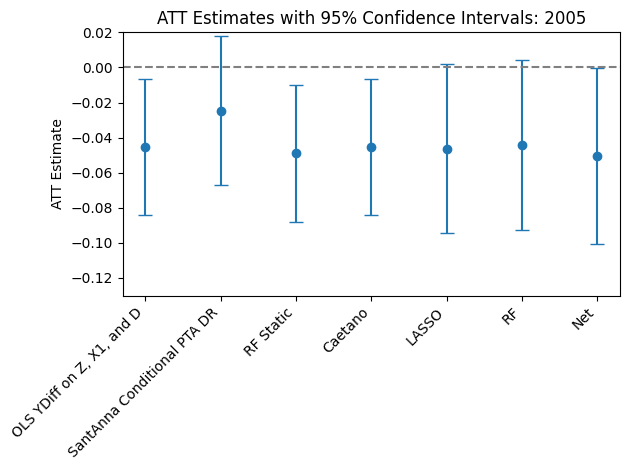

In [5]:
plot_att_estimates_with_ci(out_2005, att_2015, std_2015, 'RF Static', "2005", att_SantAnna, std_SantAnna )

## 2006

In [6]:
out_2006 = dynamic_riesz_results(2003,2006)
att_2006, std_2006 = -0.051, 0.020

att_SantAnna, std_SantAnna =  -0.0497,     0.0212 

Changing covariates:  ['lpop', 'lavg_pay']
Z variables:  ['region_2', 'region_3', 'region_4', '2001_lemp', '2001_lpop', '2001_lavg_pay']


Exception ignored in: <finalize object at 0x148a758fa740; dead>
Traceback (most recent call last):
  File "/n/home11/jinhopark/.conda/envs/riesz/lib/python3.10/weakref.py", line 591, in __call__
    return info.func(*info.args, **(info.kwargs or {}))
  File "/n/home11/jinhopark/.conda/envs/riesz/lib/python3.10/tempfile.py", line 868, in _cleanup
    cls._rmtree(name, ignore_errors=ignore_errors)
  File "/n/home11/jinhopark/.conda/envs/riesz/lib/python3.10/tempfile.py", line 864, in _rmtree
    _shutil.rmtree(name, onerror=onerror)
  File "/n/home11/jinhopark/.conda/envs/riesz/lib/python3.10/shutil.py", line 731, in rmtree
    onerror(os.rmdir, path, sys.exc_info())
  File "/n/home11/jinhopark/.conda/envs/riesz/lib/python3.10/shutil.py", line 729, in rmtree
    os.rmdir(path)
OSError: [Errno 39] Directory not empty: '/n/home11/jinhopark/tmphuvgjeel'
Exception ignored in: <finalize object at 0x148a758f5500; dead>
Traceback (most recent call last):
  File "/n/home11/jinhopark/.conda/envs/

In [15]:
out_2006 = dynamic_riesz_results(2003,2006)
att_2006, std_2006 = -0.051, 0.020

att_SantAnna, std_SantAnna =  -0.0497,     0.0212 

Changing covariates:  ['lpop', 'lavg_pay']
Z variables:  ['region_2', 'region_3', 'region_4', '2001_lemp', '2001_lpop', '2001_lavg_pay']


Exception ignored in: <finalize object at 0x1488e3cbefc0; dead>
Traceback (most recent call last):
  File "/n/home11/jinhopark/.conda/envs/riesz/lib/python3.10/weakref.py", line 591, in __call__
    return info.func(*info.args, **(info.kwargs or {}))
  File "/n/home11/jinhopark/.conda/envs/riesz/lib/python3.10/tempfile.py", line 868, in _cleanup
    cls._rmtree(name, ignore_errors=ignore_errors)
  File "/n/home11/jinhopark/.conda/envs/riesz/lib/python3.10/tempfile.py", line 864, in _rmtree
    _shutil.rmtree(name, onerror=onerror)
  File "/n/home11/jinhopark/.conda/envs/riesz/lib/python3.10/shutil.py", line 731, in rmtree
    onerror(os.rmdir, path, sys.exc_info())
  File "/n/home11/jinhopark/.conda/envs/riesz/lib/python3.10/shutil.py", line 729, in rmtree
    os.rmdir(path)
OSError: [Errno 39] Directory not empty: '/n/home11/jinhopark/tmp3iyn_lo7'
Exception ignored in: <finalize object at 0x1488e3c8a3e0; dead>
Traceback (most recent call last):
  File "/n/home11/jinhopark/.conda/envs/

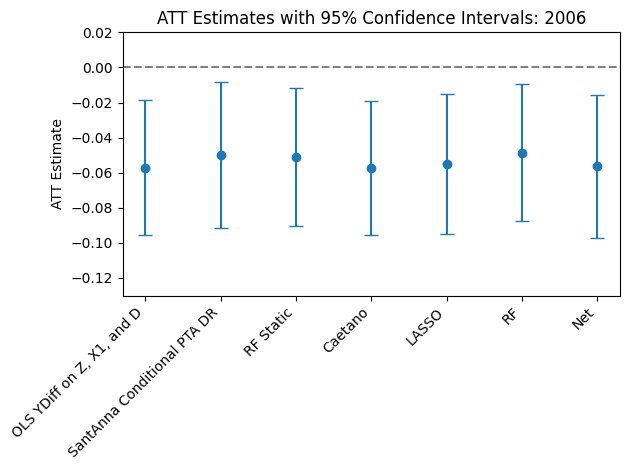

In [7]:
plot_att_estimates_with_ci(out_2006, att_2006, std_2006, 'RF Static', "2006", att_SantAnna, std_SantAnna )

## 2007

In [8]:
out_2007 = dynamic_riesz_results(2003,2007)
att_2007, std_2007 = -0.064, 0.023
att_SantAnna, std_SantAnna= -0.0709    , 0.0232  

Changing covariates:  ['lpop', 'lavg_pay']
Z variables:  ['region_3', 'region_4', '2001_lemp', '2001_lpop', '2001_lavg_pay']


Exception ignored in: <finalize object at 0x148a758fefa0; dead>
Traceback (most recent call last):
  File "/n/home11/jinhopark/.conda/envs/riesz/lib/python3.10/weakref.py", line 591, in __call__
    return info.func(*info.args, **(info.kwargs or {}))
  File "/n/home11/jinhopark/.conda/envs/riesz/lib/python3.10/tempfile.py", line 868, in _cleanup
    cls._rmtree(name, ignore_errors=ignore_errors)
  File "/n/home11/jinhopark/.conda/envs/riesz/lib/python3.10/tempfile.py", line 864, in _rmtree
    _shutil.rmtree(name, onerror=onerror)
  File "/n/home11/jinhopark/.conda/envs/riesz/lib/python3.10/shutil.py", line 731, in rmtree
    onerror(os.rmdir, path, sys.exc_info())
  File "/n/home11/jinhopark/.conda/envs/riesz/lib/python3.10/shutil.py", line 729, in rmtree
    os.rmdir(path)
OSError: [Errno 39] Directory not empty: '/n/home11/jinhopark/tmp_htz0e9h'
Exception ignored in: <finalize object at 0x148a758fed00; dead>
Traceback (most recent call last):
  File "/n/home11/jinhopark/.conda/envs/

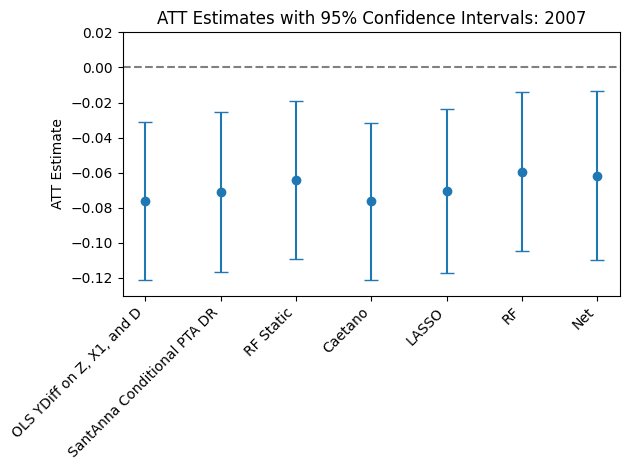

In [9]:
plot_att_estimates_with_ci(out_2007, att_2007, std_2007, 'RF Static', "2007", att_SantAnna, std_SantAnna )

All results computed here.

Overall progress:   0%|          | 0/2 [00:00<?, ?it/s]

Changing covariates:  ['lpop', 'lavg_pay']
Z variables:  ['region_2', 'region_3', 'region_4', '2001_lemp', '2001_lpop', '2001_lavg_pay']











Year 2006: 100%|██████████| 5/5 [12:39<00:00, 151.88s/it, Net]


[2006] computed and cached to: application_results_final/min_wage_cache/results_2006.csv


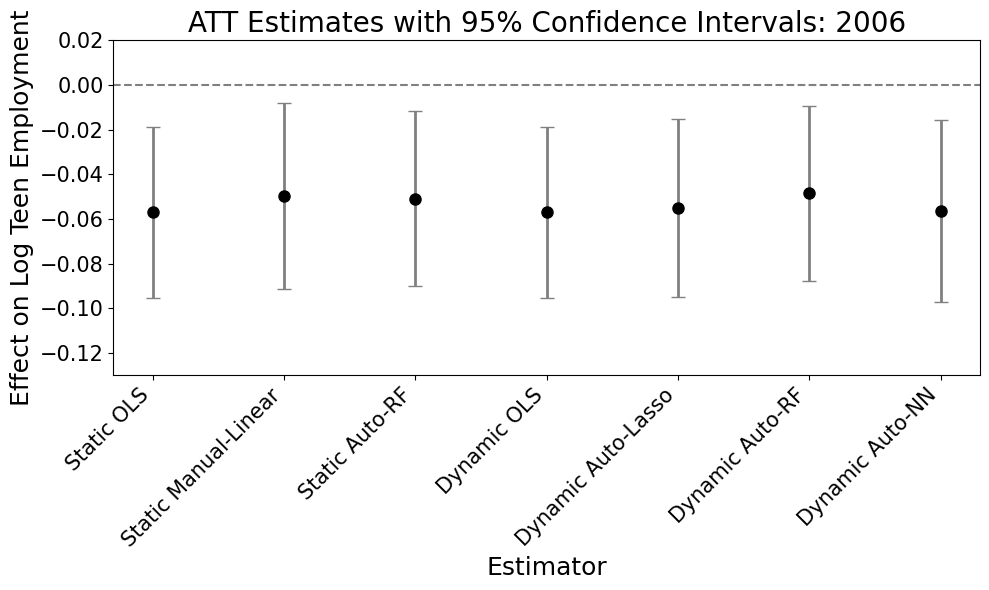

Overall progress:  50%|█████     | 1/2 [12:40<12:40, 760.10s/it]

Changing covariates:  ['lpop', 'lavg_pay']
Z variables:  ['region_3', 'region_4', '2001_lemp', '2001_lpop', '2001_lavg_pay']


In [ ]:
import os
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
from tqdm import tqdm

from utils.dynamicRieszFunctions import estimateDynamicRiesz
from utils.estimateDiD_OLS import estimateDiD_OLS
from utils.application import *

# ---------------------------------------------------------------
# Hardcoded "Static" results (computed elsewhere; pasted in here)
# ---------------------------------------------------------------
STATIC_RESULTS = {
    2004: {"Static Auto-RF": (-0.022, 0.019), "Static Manual-Linear": (-0.0303, 0.0225)},
    2005: {"Static Auto-RF": (-0.049, 0.020), "Static Manual-Linear": (-0.0247, 0.0217)},
    2006: {"Static Auto-RF": (-0.051, 0.020), "Static Manual-Linear": (-0.0497, 0.0212)},
    2007: {"Static Auto-RF": (-0.064, 0.023), "Static Manual-Linear": (-0.0709, 0.0232)},
}

DYNAMIC_RENAME = {
    "OLS YDiff on Z, X1, and D": "Static OLS",
    "Caetano": "Dynamic OLS",
    "LASSO": "Dynamic Auto-Lasso",
    "RF": "Dynamic Auto-RF",
    "Net": "Dynamic Auto-NN",
}

TITLE_SIZE = 20
AXIS_LABEL_SIZE = 18
TICK_LABEL_SIZE = 15

RESULTS_DIR = "application_results_final/min_wage_cache"
os.makedirs(RESULTS_DIR, exist_ok=True)


def dynamic_riesz_results(start_year, effect_year, treatment_year=2004,
                           baseline_2001=True, folds=5, seed=0, verbose=True):
    data_app = application_data()
    data = data_app.get_data(start_year, effect_year, treatment_year=treatment_year,
                              baseline_2001=baseline_2001)
    X1, X2 = data['X1'], data['X2']
    Y1, Y2 = data['Y1'], data['Y2']
    Z, D = data['Z'], data['D']

    Z_df = pd.DataFrame(Z.numpy())
    X1_df = pd.DataFrame(X1.numpy())

    X_cov = pd.concat([pd.DataFrame(D.numpy(), columns=["D"]), Z_df, X1_df], axis=1)
    Ydiff = np.asarray(Y2) - np.asarray(Y1)
    X_cov = sm.add_constant(X_cov)

    steps = ["OLS", "Caetano", "LASSO", "RF", "Net"]
    pbar = tqdm(steps, desc=f"Year {effect_year}", disable=not verbose)

    rows = []

    pbar.set_postfix_str("OLS")
    ols2 = sm.OLS(Ydiff, X_cov).fit(cov_type="HC1")
    rows.append({
        "method": "OLS YDiff on Z, X1, and D",
        "ATT": float(ols2.params["D"]),
        "SE": float(ols2.bse["D"])
    })
    pbar.update(1)

    pbar.set_postfix_str("Caetano")
    lin_out = estimateDiD_OLS(Y1, Y2, D, Z, X1, X2, seed=seed)
    rows.append({"method": "Caetano", "ATT": lin_out[0], "SE": lin_out[1]})
    pbar.update(1)

    for method in ("LASSO", "RF", "Net"):
        pbar.set_postfix_str(method)
        ATT, STD, *_ = estimateDynamicRiesz(
            Y1, Y2, D, Z, X1, X2, folds,
            method_a=method, method_f=method, seed=seed
        )
        se = STD / np.sqrt(len(Y1))
        rows.append({"method": method, "ATT": ATT.item(), "SE": se.item()})
        pbar.update(1)

    pbar.close()
    return pd.DataFrame(rows)


def get_or_compute_results(year, force_recompute=False, verbose=True):
    cache_path = os.path.join(RESULTS_DIR, f"results_{year}.csv")
    if os.path.exists(cache_path) and not force_recompute:
        if verbose:
            print(f"[{year}] loaded from cache: {cache_path}")
        return pd.read_csv(cache_path)
    out_df = dynamic_riesz_results(2003, year, verbose=verbose)
    out_df.to_csv(cache_path, index=False)
    if verbose:
        print(f"[{year}] computed and cached to: {cache_path}")
    return out_df


def plot_att_estimates(year, force_recompute=False, verbose=True):
    out_df = get_or_compute_results(year, force_recompute=force_recompute, verbose=verbose)
    out_df = out_df.copy()
    out_df["method"] = out_df["method"].replace(DYNAMIC_RENAME)

    static_rows = pd.DataFrame([
        {"method": name, "ATT": vals[0], "SE": vals[1]}
        for name, vals in STATIC_RESULTS[year].items()
    ])

    plot_df = pd.concat([out_df, static_rows], ignore_index=True)

    method_order = [
        "Static OLS", "Static Manual-Linear", "Static Auto-RF",
        "Dynamic OLS", "Dynamic Auto-Lasso", "Dynamic Auto-RF", "Dynamic Auto-NN",
    ]
    plot_df["method"] = pd.Categorical(plot_df["method"], categories=method_order, ordered=True)
    plot_df = plot_df.sort_values("method")

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.errorbar(
        plot_df['method'], plot_df['ATT'],
        yerr=1.96 * plot_df['SE'],
        fmt='o', capsize=5, markersize=8, color='black', ecolor='gray', elinewidth=2
    )
    ax.axhline(0, linestyle='--', color='gray')
    ax.set_xlabel('Estimator', fontsize=AXIS_LABEL_SIZE)
    ax.set_ylabel('Effect on Log Teen Employment', fontsize=AXIS_LABEL_SIZE)
    ax.set_title(f'ATT Estimates with 95% Confidence Intervals: {year}', fontsize=TITLE_SIZE)
    ax.set_ylim(-0.13, 0.02)
    ax.tick_params(axis='x', labelsize=TICK_LABEL_SIZE, rotation=45)
    ax.tick_params(axis='y', labelsize=TICK_LABEL_SIZE)
    plt.setp(ax.get_xticklabels(), ha="right")
    plt.tight_layout()
    plt.show()

    return plot_df


# ---------------------------------------------------------------
# Generate all four years, with an overall progress bar too
# ---------------------------------------------------------------
years = (2006, 2007)
for year in tqdm(years, desc="Overall progress"):
    plot_att_estimates(year)